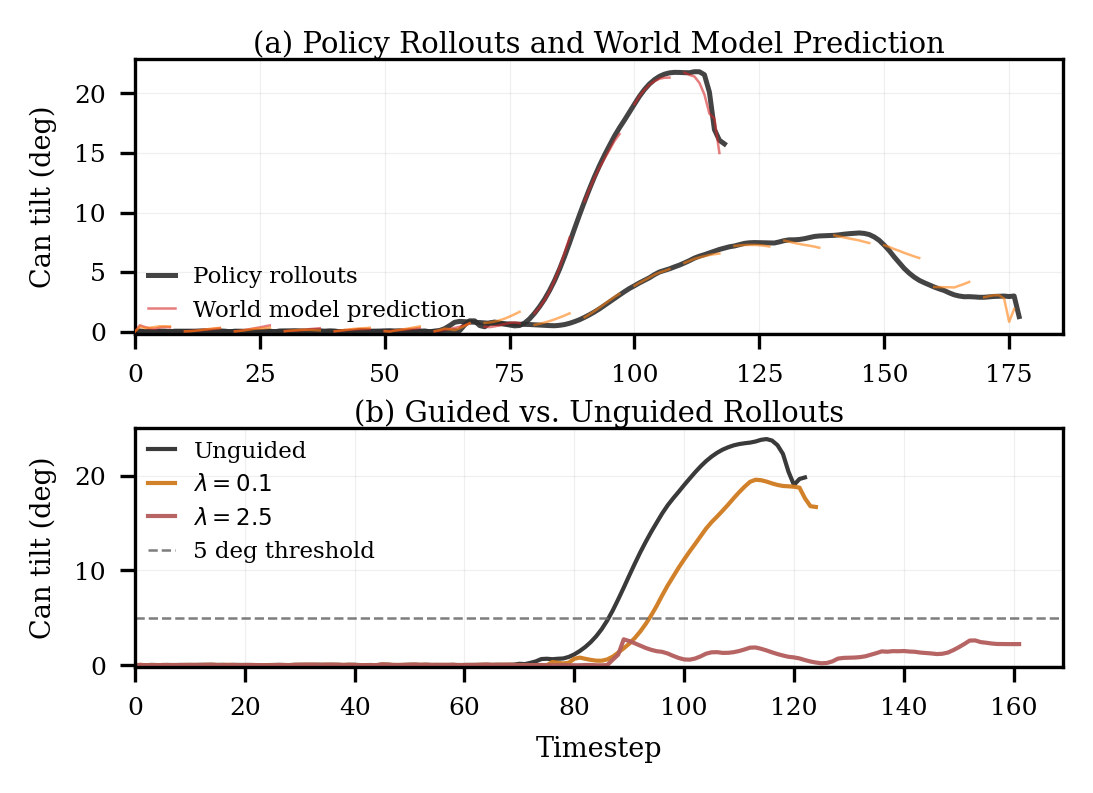

Saved PNG to: outputs/guidance_artifacts/seeded_guided_diffusion_seed_3/paper_two_panel_diffusion_and_guidance.png
Saved PDF to: outputs/guidance_artifacts/seeded_guided_diffusion_seed_3/paper_two_panel_diffusion_and_guidance.pdf
Figure size in inches: [3.5 2.5]


In [17]:
from pathlib import Path
import pickle
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make local guidance utilities importable from the figures/ notebook directory
sys.path.append(str((Path("..") / "guidance").resolve()))
sys.path.append(str((Path(".") / "guidance").resolve()))
from world_model_utils import (
    build_state_from_obs_dict,
    load_model_for_eval,
    rzz_from_state_29d,
    predict_next_state_from_raw,
)

# -----------------------------
# Shared paper-style settings
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 6.5,
    "axes.titlesize": 7,
    "axes.titleweight": "normal",
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 5.5,
})

# -----------------------------
# Helpers
# -----------------------------
def load_states_from_trace(trace_path: Path) -> np.ndarray:
    with open(trace_path, "rb") as f:
        trace = pickle.load(f)

    if isinstance(trace, dict):
        if "states" in trace:
            return np.asarray(trace["states"], dtype=np.float32)
        for key in ("rollout", "trajectory", "episode", "data"):
            nested = trace.get(key)
            if isinstance(nested, dict) and "states" in nested:
                return np.asarray(nested["states"], dtype=np.float32)

    if isinstance(trace, (list, tuple)) and trace:
        first = trace[0]
        if isinstance(first, dict):
            if "states" in first:
                return np.asarray([row["states"] for row in trace], dtype=np.float32)
            if "obs" in first:
                return np.asarray([build_state_from_obs_dict(row["obs"]) for row in trace], dtype=np.float32)
        try:
            return np.asarray(trace, dtype=np.float32)
        except (TypeError, ValueError):
            pass

    raise ValueError(f"Could not find states in trace file: {trace_path}")


def rollout_rzz_from_trace(trace_path: Path) -> np.ndarray:
    states = load_states_from_trace(trace_path)
    return np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)


def rzz_to_tilt_deg(rzz: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(rzz, dtype=np.float32), -1.0, 1.0)
    return np.degrees(np.arccos(clipped)).astype(np.float32)


# -----------------------------
# Load data for (a) Diffusion Policy Behavior
# -----------------------------
run_dir = Path("./outputs/can_rollouts/diffusion_guidance_checks/20260404_135244")
rollout_pkl = run_dir / "seed_rollouts_full.pkl"
with open(rollout_pkl, "rb") as f:
    seed_rollouts = pickle.load(f)

all_trajs = []
for seed_name in sorted(seed_rollouts.keys()):
    for rep_idx, rollout in enumerate(seed_rollouts[seed_name], start=1):
        all_trajs.append((seed_name, rep_idx, rollout))
selected_trajs = all_trajs[:2]

device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
predictor, stats, _, eval_meta = load_model_for_eval(
    model_or_run_path="./models/dynamics/baseline_mlp",
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)

# -----------------------------
# Load data for (b) Guidance Scale
# -----------------------------
artifact_root = Path("./outputs/guidance_artifacts/seeded_guided_diffusion_seed_3")
late_guidance_root = Path(
    "./outputs/can_rollouts/guidance_scheduling/late_guidance/full_rollout"
)

scales_to_plot = [0, 0.1, 2.5]
label_map = {
    0: "Unguided",
    0.1: r"$\lambda = 0.1$",
    2.5: r"$\lambda = 2.5$",
}
# Muted warm palette (distinct from world-model branch colors)
color_map = {
    0: "#2f2f2f",
    0.1: "#d07a1f",
    2.5: "#b35c5c",
}

rzz_series = {}
for s in scales_to_plot:
    if s == 0:
        npz_path = artifact_root / "scale_0_seed_3" / "rollout_numeric.npz"
        if not npz_path.exists():
            raise FileNotFoundError(f"Missing rollout file: {npz_path}")
        data = np.load(npz_path)
        rzz_series[s] = np.asarray(data["rzz_mujoco"], dtype=np.float32)
    else:
        folder_name = f"n16h300r60g1bYfYv1_seed05_Ga10scale{s}"
        trace_path = late_guidance_root / folder_name / "guided_post_sample" / "rollout_trace.pkl"
        if not trace_path.exists():
            trace_path = late_guidance_root / folder_name / "guided_post_sample_trace.pkl"
        if not trace_path.exists():
            trace_path = late_guidance_root / folder_name / "guided_post_sample" / "trace.pkl"
        if not trace_path.exists():
            raise FileNotFoundError(f"Missing rollout trace file: {trace_path}")
        rzz_series[s] = rollout_rzz_from_trace(trace_path)

# -----------------------------
# Build combined figure
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 2.5),
    dpi=300,
    gridspec_kw={"height_ratios": [1.15, 1.0]},
)

# (a) Diffusion Policy Behavior, expressed as can tilt instead of raw Rzz.
ax = axes[0]
branch_horizon = 8
branch_stride = 10

true_color = "#2f2f2f"
branch_colors = ["#d62728", "#ff7f0e"]

for traj_idx, (seed_name, rep_idx, rollout) in enumerate(selected_trajs):
    states = rollout["states"]
    actions = rollout["actions"]
    t_actions = len(actions)

    true_rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    true_tilt = rzz_to_tilt_deg(true_rzz)
    ax.plot(
        np.arange(len(true_tilt)),
        true_tilt,
        color=true_color,
        linewidth=1.2,
        alpha=0.90,
        label="Policy rollouts" if traj_idx == 0 else None,
        zorder=2,
    )

    first_branch = True
    for t0 in range(0, t_actions, branch_stride):
        s_roll = np.asarray(states[t0], dtype=np.float32).copy()
        branch_rzz = [true_rzz[t0]]
        k_max = min(branch_horizon, t_actions - t0)
        for k in range(k_max):
            a_k = actions[t0 + k]
            s_roll = predict_next_state_from_raw(s_roll, a_k, predictor, stats, device)
            branch_rzz.append(rzz_from_state_29d(s_roll))

        branch_tilt = rzz_to_tilt_deg(np.asarray(branch_rzz, dtype=np.float32))[:-1]
        x_branch = np.arange(t0, t0 + len(branch_tilt))
        ax.plot(
            x_branch,
            branch_tilt,
            color=branch_colors[traj_idx],
            linewidth=0.6,
            alpha=0.60,
            label="World model prediction" if (traj_idx == 0 and first_branch) else None,
            zorder=3,
        )
        first_branch = False

ax.set_title("(a) Policy Rollouts and World Model Prediction", pad=1.5, fontsize=7, fontweight="normal")
ax.set_ylabel("Can tilt (deg)", fontsize=6.5)
ax.grid(alpha=0.2, linewidth=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=-0.2)
ax.legend(loc="lower left", frameon=False, ncol=1, handlelength=1.2, borderaxespad=0.15)

# (b) Guidance Scale
ax = axes[1]
for s in scales_to_plot:
    tilt_deg = rzz_to_tilt_deg(rzz_series[s])
    ax.plot(
        np.arange(len(tilt_deg)),
        tilt_deg,
        color=color_map[s],
        linewidth=1,
        alpha=0.95,
        label=label_map[s],
    )

ax.axhline(
    5.0,
    color="#666666",
    linestyle="--",
    linewidth=0.6,
    alpha=0.85,
    label="5 deg threshold",
)

ax.set_title("(b) Guided vs. Unguided Rollouts", pad=1.5, fontsize=7, fontweight="normal")
ax.set_xlabel("Timestep", fontsize=6.5)
ax.set_ylabel("Can tilt (deg)", fontsize=6.5)
ax.grid(alpha=0.2, linewidth=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=-0.2)
ax.legend(loc="upper left", frameon=False, ncol=1, handlelength=1.2, columnspacing=0.8, borderaxespad=0.15)

fig.tight_layout(pad=0.2, h_pad=0.3)

# Keep exact physical export size: do NOT use bbox_inches='tight'
combined_png = artifact_root / "paper_two_panel_diffusion_and_guidance.png"
combined_pdf = artifact_root / "paper_two_panel_diffusion_and_guidance.pdf"
fig.savefig(combined_png, dpi=600)
fig.savefig(combined_pdf)
plt.show()

print(f"Saved PNG to: {combined_png}")
print(f"Saved PDF to: {combined_pdf}")
print(f"Figure size in inches: {fig.get_size_inches()}")

lambda=0.1
  trace length: 125
  Rzz range: 0.9423254728317261 1.0
  any values outside [-1, 1]?: False
  max |ΔRzz|: 0.0061383843421936035
  max |Δtilt| (deg): 1.128305435180664
  median |d tilt / d rzz|: 65533.20703125
  95th pct |d tilt / d rzz|: 312450.77499999973
  median theoretical gain: 70980.375
  95th pct theoretical gain: 57295780.0

lambda=2.5
  trace length: 162
  Rzz range: 0.9988600015640259 1.0000001192092896
  any values outside [-1, 1]?: True
  max |ΔRzz|: 0.0009483098983764648
  max |Δtilt| (deg): 1.614223837852478
  median |d tilt / d rzz|: 5445.7822265625
  95th pct |d tilt / d rzz|: 331892.59375
  median theoretical gain: 67747.296875
  95th pct theoretical gain: 57295780.0



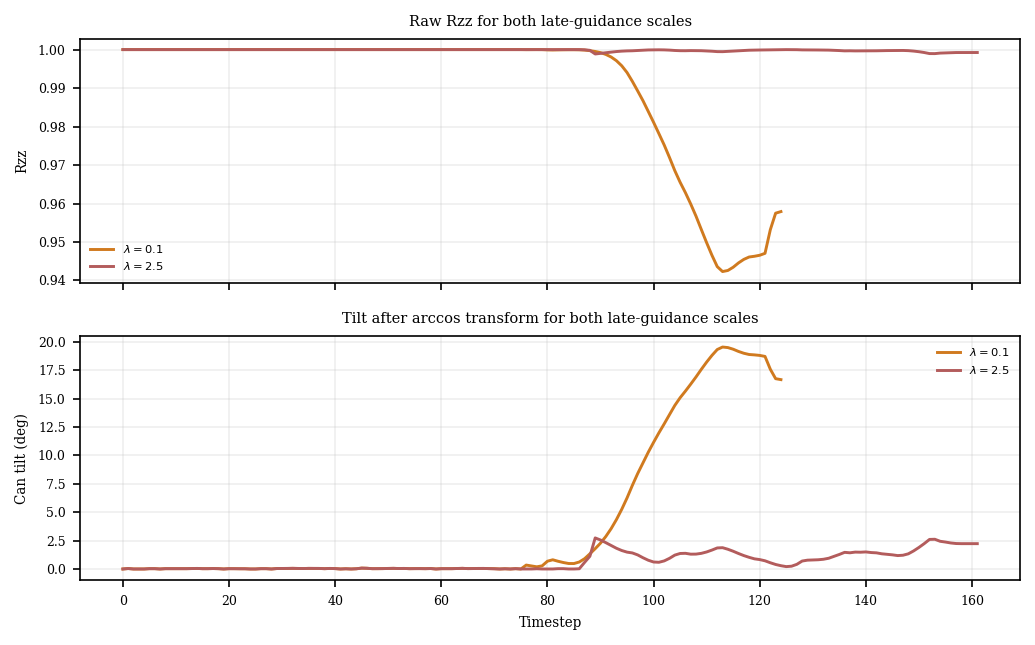

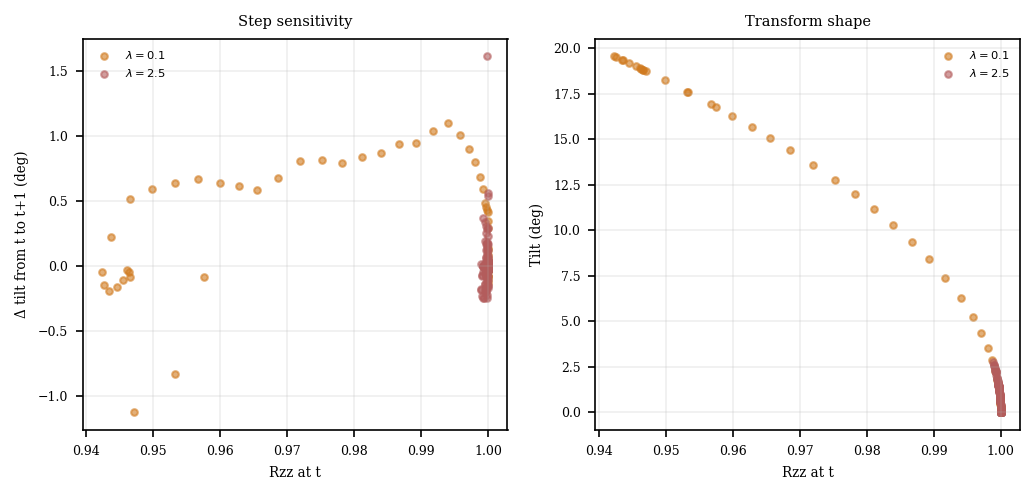

Interpretation:
- If both curves are close to 1.0, arccos is highly nonlinear in the region you care about.
- The same tiny Rzz wiggles can therefore look much larger in degrees, especially when one trace sits closer to 1.0 than the other.
- That is expected math, not a bug, unless the underlying Rzz itself looks wrong or leaves the physical range by much more than floating-point noise.


In [15]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

# Compare the same transform for both late-guidance scales.
late_guidance_root = Path("./outputs/can_rollouts/guidance_scheduling/late_guidance/full_rollout")
trace_specs = {
    0.1: late_guidance_root / "n16h300r60g1bYfYv1_seed05_Ga10scale0.1" / "guided_post_sample" / "rollout_trace.pkl",
    2.5: late_guidance_root / "n16h300r60g1bYfYv1_seed05_Ga10scale2.5" / "guided_post_sample" / "rollout_trace.pkl",
}
colors = {0.1: "#d07a1f", 2.5: "#b35c5c"}
labels = {0.1: r"$\lambda = 0.1$", 2.5: r"$\lambda = 2.5$"}


def load_trace_states(trace_path: Path) -> np.ndarray:
    with open(trace_path, "rb") as f:
        trace = pickle.load(f)
    if isinstance(trace, dict) and "states" in trace:
        return np.asarray(trace["states"], dtype=np.float32)
    if isinstance(trace, (list, tuple)) and trace:
        first = trace[0]
        if isinstance(first, dict) and "obs" in first:
            return np.asarray([build_state_from_obs_dict(row["obs"]) for row in trace], dtype=np.float32)
        if isinstance(first, dict) and "states" in first:
            return np.asarray([row["states"] for row in trace], dtype=np.float32)
    raise ValueError(f"Unexpected trace format: {trace_path}")


def tilt_from_rzz(rzz: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(rzz, dtype=np.float32), -1.0, 1.0)
    return np.degrees(np.arccos(clipped)).astype(np.float32)


series = {}
for lam, trace_path in trace_specs.items():
    states = load_trace_states(trace_path)
    rzz = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
    tilt = tilt_from_rzz(rzz)
    clipped = np.clip(rzz, -1.0, 1.0)
    delta_rzz = np.diff(rzz)
    delta_tilt = np.diff(tilt)
    with np.errstate(divide="ignore", invalid="ignore"):
        local_gain = np.abs(delta_tilt / delta_rzz)
    local_gain = local_gain[np.isfinite(local_gain)]
    theoretical_gain = 180.0 / np.pi / np.sqrt(np.maximum(1.0 - clipped[:-1] ** 2, 1e-12))

    series[lam] = {
        "states": states,
        "rzz": rzz,
        "tilt": tilt,
        "delta_rzz": delta_rzz,
        "delta_tilt": delta_tilt,
        "local_gain": local_gain,
        "theoretical_gain": theoretical_gain,
    }

    print(f"lambda={lam}")
    print("  trace length:", len(rzz))
    print("  Rzz range:", float(np.min(rzz)), float(np.max(rzz)))
    print("  any values outside [-1, 1]?:", bool(np.any((rzz < -1.0) | (rzz > 1.0))))
    print("  max |ΔRzz|:", float(np.max(np.abs(delta_rzz))) if len(delta_rzz) else float("nan"))
    print("  max |Δtilt| (deg):", float(np.max(np.abs(delta_tilt))) if len(delta_tilt) else float("nan"))
    print("  median |d tilt / d rzz|:", float(np.median(local_gain)) if len(local_gain) else float("nan"))
    print("  95th pct |d tilt / d rzz|:", float(np.percentile(local_gain, 95)) if len(local_gain) else float("nan"))
    print("  median theoretical gain:", float(np.median(theoretical_gain)) if len(theoretical_gain) else float("nan"))
    print("  95th pct theoretical gain:", float(np.percentile(theoretical_gain, 95)) if len(theoretical_gain) else float("nan"))
    print()

fig, axes = plt.subplots(2, 1, figsize=(7.0, 4.4), dpi=150, sharex=True)
for lam in [0.1, 2.5]:
    axes[0].plot(series[lam]["rzz"], color=colors[lam], lw=1.4, label=labels[lam])
    axes[1].plot(series[lam]["tilt"], color=colors[lam], lw=1.4, label=labels[lam])

axes[0].set_ylabel("Rzz")
axes[0].set_title("Raw Rzz for both late-guidance scales")
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

axes[1].set_ylabel("Can tilt (deg)")
axes[1].set_xlabel("Timestep")
axes[1].set_title("Tilt after arccos transform for both late-guidance scales")
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.4), dpi=150)
for lam in [0.1, 2.5]:
    axes[0].scatter(series[lam]["rzz"][:-1], series[lam]["delta_tilt"], s=10, alpha=0.6, color=colors[lam], label=labels[lam])
    axes[1].scatter(series[lam]["rzz"][:-1], series[lam]["tilt"][:-1], s=10, alpha=0.6, color=colors[lam], label=labels[lam])

axes[0].set_xlabel("Rzz at t")
axes[0].set_ylabel("Δ tilt from t to t+1 (deg)")
axes[0].set_title("Step sensitivity")
axes[0].grid(alpha=0.2)
axes[0].legend(frameon=False)

axes[1].set_xlabel("Rzz at t")
axes[1].set_ylabel("Tilt (deg)")
axes[1].set_title("Transform shape")
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

print("Interpretation:")
print("- If both curves are close to 1.0, arccos is highly nonlinear in the region you care about.")
print("- The same tiny Rzz wiggles can therefore look much larger in degrees, especially when one trace sits closer to 1.0 than the other.")
print("- That is expected math, not a bug, unless the underlying Rzz itself looks wrong or leaves the physical range by much more than floating-point noise.")